In [1]:
using Pkg
Pkg.activate(joinpath(@__DIR__, "..", "..", ".."))  # go up three levels (from PauliSampling.jl\numerics\quantumboltzmannmachine\ceofficient_truncation to to PauliSampling.jl)

  Activating project at `~/Desktop/PauliSampling.jl`


In [2]:
# # Ensure packages are installed
# for pkg in [
#     "PauliPropagation", "Plots", "LinearAlgebra", "ProgressMeter", "Distributions",
#     "Random", "Optimisers", "ReverseDiff", "MAT", "BenchmarkTools", "IterTools", "StatsBase", "LaTeXStrings", "Measures", "CSV", "DataFrames", "JSON3", "Dates", "PyPlot", "SparseArrays"
# ]
#     Pkg.add(pkg)
# end

In [3]:
# Load all packages
using PauliSampling, PauliPropagation, LinearAlgebra, ProgressMeter, Statistics, Printf, Distributions, Random, Optimisers, ReverseDiff, MAT, BenchmarkTools, IterTools, StatsBase, LaTeXStrings, Measures, CSV, DataFrames, JSON3, Dates, Plots # PyPlot

# Fixed coeff truncation and varying $\beta_\text{target}$

## TFIM

### 6 qubits

Target

In [4]:
nq = 6
target_beta = 1.

rng = MersenneTwister(3)
target_interaction = rand(rng, Uniform(-1, 1))
target_field = rand(rng, Uniform(-1, 1))

params_target = parameters(:tfim, nq; field_vals=Dict(:X => target_field), coupling_vals=Dict(:ZZ => target_interaction))
target_H_paulis = makehamiltonian(params_target; connectivity=:nearest, periodic=false) * target_beta

target_H_matrix = paulistringtomatrix(target_H_paulis);

In [5]:
target_H_paulis_2 = makehamiltonian_matrix(params_target; connectivity=:nearest, periodic=false) * target_beta
target_H_paulis_2

64×64 SparseArrays.SparseMatrixCSC{ComplexF64, Int64} with 448 stored entries:
⎡⢟⣵⠑⢄⠑⢄⠀⠀⠑⢄⠀⠀⠀⠀⠀⠀⠑⢄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎤
⎢⠑⢄⢟⣵⠀⠀⠑⢄⠀⠀⠑⢄⠀⠀⠀⠀⠀⠀⠑⢄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠑⢄⠀⠀⢟⣵⠑⢄⠀⠀⠀⠀⠑⢄⠀⠀⠀⠀⠀⠀⠑⢄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠑⢄⠑⢄⢟⣵⠀⠀⠀⠀⠀⠀⠑⢄⠀⠀⠀⠀⠀⠀⠑⢄⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠑⢄⠀⠀⠀⠀⠀⠀⢟⣵⠑⢄⠑⢄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠑⢄⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠑⢄⠀⠀⠀⠀⠑⢄⢟⣵⠀⠀⠑⢄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠑⢄⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠑⢄⠀⠀⠑⢄⠀⠀⢟⣵⠑⢄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠑⢄⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠑⢄⠀⠀⠑⢄⠑⢄⢟⣵⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠑⢄⎥
⎢⠑⢄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⢟⣵⠑⢄⠑⢄⠀⠀⠑⢄⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠑⢄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠑⢄⢟⣵⠀⠀⠑⢄⠀⠀⠑⢄⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠑⢄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠑⢄⠀⠀⢟⣵⠑⢄⠀⠀⠀⠀⠑⢄⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠑⢄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠑⢄⠑⢄⢟⣵⠀⠀⠀⠀⠀⠀⠑⢄⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠑⢄⠀⠀⠀⠀⠀⠀⠑⢄⠀⠀⠀⠀⠀⠀⢟⣵⠑⢄⠑⢄⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠑⢄⠀⠀⠀⠀⠀⠀⠑⢄⠀⠀⠀⠀⠑⢄⢟⣵⠀⠀⠑⢄⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠑⢄⠀⠀⠀⠀⠀⠀⠑⢄⠀⠀⠑⢄⠀⠀⢟⣵⠑⢄⎥
⎣⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠑⢄⠀⠀⠀⠀⠀⠀⠑⢄⠀⠀⠑⢄⠑⢄⢟⣵⎦

In [6]:
target_eta_matrix_2 = makethermalstate_matrix(target_H_paulis_2, target_beta)

64×64 Matrix{ComplexF64}:
   0.0256482+0.0im   0.00667346+0.0im  …   1.05617e-5+0.0im
  0.00667346+0.0im    0.0208055+0.0im      3.53248e-5+0.0im
  0.00604345+0.0im    0.0016733+0.0im      3.40761e-5+0.0im
  0.00179954+0.0im   0.00599789+0.0im     0.000130926+0.0im
  0.00604185+0.0im   0.00157242+0.0im      3.40664e-5+0.0im
  0.00157249+0.0im   0.00490384+0.0im  …  0.000114405+0.0im
  0.00162372+0.0im  0.000451078+0.0im     0.000126295+0.0im
 0.000485392+0.0im   0.00162319+0.0im     0.000485392+0.0im
  0.00604185+0.0im   0.00157204+0.0im      3.40664e-5+0.0im
  0.00157204+0.0im   0.00490109+0.0im     0.000113958+0.0im
            ⋮                          ⋱  
  3.40664e-5+0.0im  0.000113921+0.0im  …   0.00604185+0.0im
 0.000485392+0.0im  0.000126295+0.0im     0.000485392+0.0im
 0.000126295+0.0im  0.000393745+0.0im      0.00162372+0.0im
 0.000114405+0.0im   3.16766e-5+0.0im      0.00157249+0.0im
  3.40664e-5+0.0im  0.000113545+0.0im      0.00604185+0.0im
 0.000130926+0.0im   3.40745e-5

In [7]:
targert_circuit, target_θ = paulistringtocircuit(target_H_paulis)

num_layers_target = 10
max_weight_target = nq
min_abs_coeff_target = 1e-10
target_eta = makethermalstate(nq, targert_circuit, target_θ, num_layers_target;
                                  max_weight=max_weight_target,
                                  min_abs_coeff=min_abs_coeff_target)
target_eta_matrix = paulistringtomatrix(target_eta)
target_probs = computesymmetriceigenvalues(target_eta_matrix);

QBM Learning

In [17]:
# --- Initialization ---
beta = rand(rng, Uniform(0, 10))    
params = params_target
qbm_H_paulis = makehamiltonian(params; connectivity=:nearest, periodic=false) * beta

# learning rate
gamma = 0.2
# number of epochs
epochs = 1000
# stop when gradient is smaller than epsilon, at the final number of epochs
epsilon = 1e-6
# keep track of loss and gradients
qre_hist = Float64[]
grad_hist = Vector{Float64}[]

num_layers = 10
max_weight = nq
min_abs_coeff = 1e-10

for epoch in 1:epochs
    # Build Hamiltonian matrix
    qbm_H_matrix = paulistringtomatrix(qbm_H_paulis)
    push!(qre_hist, computequantumrelativeentropy(target_eta_matrix, target_probs, qbm_H_matrix))

    # Create thermal state
    circuit, theta = paulistringtocircuit(qbm_H_paulis)
    rho = makethermalstate(nq, circuit, theta, num_layers;
                            max_weight=max_weight, min_abs_coeff=min_abs_coeff)

    # --- Gradient computation (efficient) ---
    grads = computegradients(qbm_H_paulis, target_eta_matrix, rho)
    push!(grad_hist, abs.(grads))

    # --- Parameter update ---
    updatehamiltonian!(qbm_H_paulis, grads, gamma)

    # --- Diagnostics ---
    if epoch % 100 == 0
        @printf("\nEpoch %d\n", epoch)
        @printf("  Quantum relative entropy: %.6f\n", qre_hist[end])
        @printf("  Max abs gradient:         %.6f\n", maximum(grad_hist[end]))
    end

    # --- Convergence ---
    if maximum(grad_hist[end]) < epsilon
        println("Converged: max gradient < epsilon")
        break
    end
end

Converged: max gradient < epsilon


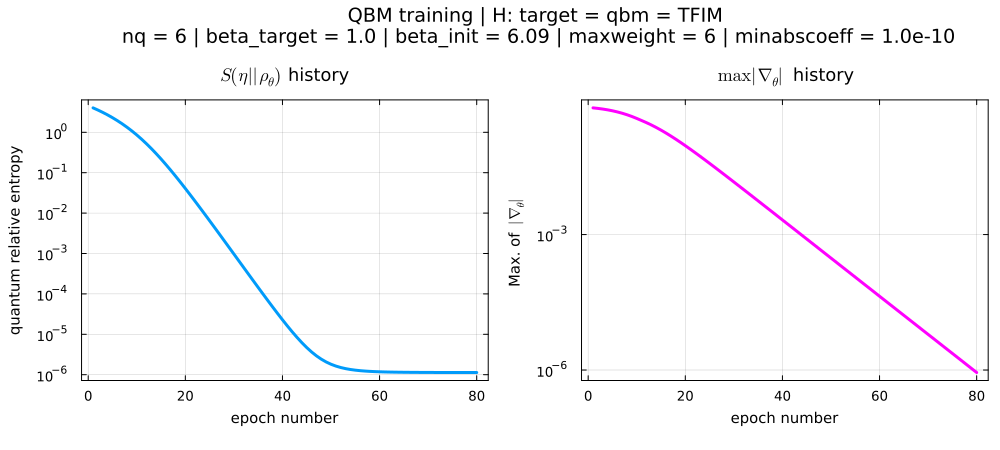

In [18]:
gr()

# ---- First plot ----
p1 = plot(qre_hist,
    # xaxis = :log10,
    yaxis = :log10,
    xlabel = "epoch number",
    ylabel = "quantum relative entropy",
    title = "\n" * "\n" * string(L"S\left(\!\eta || \!\rho\!_\theta\!\right)", " history"),
    legend = false,
    lw = 3,
    titlefont = font(12),
    guidefont = font(10),
    tickfont = font(9),
    margin = 5mm)

# ---- Second plot ----
p2 = plot([maximum(g) for g in grad_hist],
    # xaxis = :log10,
    yaxis = :log10,
    xlabel = "epoch number",
    ylabel = "Max. of  " * L"|\!\nabla\!_\theta|",
    title = "\n" * "\n" * string(L"\max |\!\nabla\!_\theta|", " history"),  
    legend = false,
    color = :fuchsia,
    lw = 3,
    titlefont = font(12),
    guidefont = font(10),
    tickfont = font(9),
    margin = 5mm)

# ---- Combine side by side ----
combined = plot(
    p1, p2,
    layout = (1, 2),
    size = (1000, 450),
    plot_title = "QBM training | H: target = qbm = TFIM\n nq = $(nq) | beta_target = $(round(target_beta, digits=1)) | beta_init = $(round(beta, digits=2)) | maxweight = $(max_weight) | minabscoeff = $(@sprintf("%.1e", min_abs_coeff))",
    plot_titlefont = font(13),
    bottom_margin = 9mm,  
    left_margin = 5mm,    
    right_margin = 1mm,
    top_margin = 10mm,
    framestyle = :box,
    titleloc = :center,
    spacing = 10mm       
)

display(combined)

In [400]:
target_H_paulis

11-element Vector{PauliString{UInt16, Float64}}:
 PauliString(nqubits: 6, -0.029682 * XIIIII)
 PauliString(nqubits: 6, -0.029682 * IXIIII)
 PauliString(nqubits: 6, -0.029682 * IIXIII)
 PauliString(nqubits: 6, -0.029682 * IIIXII)
 PauliString(nqubits: 6, -0.029682 * IIIIXI)
 PauliString(nqubits: 6, -0.029682 * IIIIIX)
 PauliString(nqubits: 6, -0.011051 * ZZIIII)
 PauliString(nqubits: 6, -0.011051 * IZZIII)
 PauliString(nqubits: 6, -0.011051 * IIZZII)
 PauliString(nqubits: 6, -0.011051 * IIIZZI)
 PauliString(nqubits: 6, -0.011051 * IIIIZZ)

In [401]:
qbm_H_paulis

11-element Vector{PauliString{UInt16, Float64}}:
 PauliString(nqubits: 6, -0.029683 * XIIIII)
 PauliString(nqubits: 6, -0.029683 * IXIIII)
 PauliString(nqubits: 6, -0.029683 * IIXIII)
 PauliString(nqubits: 6, -0.029683 * IIIXII)
 PauliString(nqubits: 6, -0.029683 * IIIIXI)
 PauliString(nqubits: 6, -0.029683 * IIIIIX)
 PauliString(nqubits: 6, -0.011051 * ZZIIII)
 PauliString(nqubits: 6, -0.011051 * IZZIII)
 PauliString(nqubits: 6, -0.011051 * IIZZII)
 PauliString(nqubits: 6, -0.011051 * IIIZZI)
 PauliString(nqubits: 6, -0.011051 * IIIIZZ)

In [55]:
# ----------------------------- #
#  ---  EXPERIMENT SETUP   ---  #
# ----------------------------- #

nq = 6 

rng = MersenneTwister()

# target
## target β values to test
target_beta_values = [0.1, 1.0, 10.0, 40.0]
colors = [:dodgerblue, :seagreen, :orange, :crimson]

target_interaction = rand(rng, Uniform(-1, 1))
target_field = rand(rng, Uniform(-1, 1))
params_target = parameters(:tfim, nq; field_vals=Dict(:X => target_field), coupling_vals=Dict(:ZZ => target_interaction))
target_H_paulis = makehamiltonian(params_target; connectivity=:nearest, periodic=false) 

# learning rate
gamma = 0.2
# number of epochs
epochs = 1000
# stop when gradient is smaller than epsilon
epsilon = 1e-6

# QBM values
rng = MersenneTwister()
beta_qbm = rand(rng, Uniform(0, 10))
## truncation parameters
num_layers_qbm = 100
max_weight_qbm = nq
min_abs_coeff_qbm = 1e-10


# # Output path
# save_dir = "/Users/micheleminervini/Desktop/PauliSampling.jl/numerics/quantumboltzmannmachines/data"
# base_name = "targetTFIM_qbmTFIM_6qb_notrunc"

# ----------------------------- #
#  ---  INITIALIZE PLOTS   ---  #
# ----------------------------- #

# storage for plots
p1 = plot(
    yaxis = :log10,
    xaxis = :log10,
    xlabel = "epoch number",
    ylabel = "quantum relative entropy",
    title = "\n" * "\n" * string(L"S\left(\!\eta || \!\rho\!_\theta\!\right)", " history"),
    legend = :topright,
    lw = 3,
    titlefont = font(12),
    guidefont = font(10),
    tickfont = font(9),
    margin = 5mm
)

p2 = plot(
    yaxis = :log10,
    xaxis = :log10,
    xlabel = "epoch number",
    ylabel = "Max. of  " * L"|\!\nabla\!_\theta|",
    title = "\n" * "\n" * string(L"\max |\!\nabla\!_\theta|", " history"),
    legend = :topright,
    lw = 3,
    titlefont = font(12),
    guidefont = font(10),
    tickfont = font(9),
    margin = 5mm
)

# ----------------------------- #
#  ---  MAIN OPTIMIZATION   --- #
# ----------------------------- #

# Loop over target beta values
for (i, target_beta) in enumerate(target_beta_values)

    println("\n" * "="^60)
    @printf("Starting optimization for max weight = %.3f\n", target_beta)
    println("="^60)

    #  ---  TARGET STATE SETUP  --- #
    target_H_paulis_beta = target_H_paulis
    target_H_paulis_beta *= target_beta
    targert_circuit, target_θ = paulistringtocircuit(target_H_paulis_beta)
    num_layers_target = 100
    max_weight_target = nq
    min_abs_coeff_target = 1e-20
    target_eta = makethermalstate(nq, targert_circuit, target_θ, num_layers_target;
        max_weight=max_weight_target,
        min_abs_coeff=min_abs_coeff_target
    )
    target_eta_matrix = paulistringtomatrix(target_eta)
    target_probs = computesymmetriceigenvalues(target_eta_matrix)

    #  ---  QBM MODEL & OPTIM.  --- #
    qbm_H_paulis = makehamiltonian(params_target; connectivity=:nearest, periodic=true) * beta_qbm  

    # keep track of loss and gradients
    qre_hist = Float64[]
    grad_hist = Vector{Float64}[]

    for epoch in 1:epochs
        qbm_H_matrix = paulistringtomatrix(qbm_H_paulis)
        push!(qre_hist, computequantumrelativeentropy(target_eta_matrix, target_probs, qbm_H_matrix))

        # create qbm state
        circuit, theta = paulistringtocircuit(qbm_H_paulis)
        rho = makethermalstate(nq, circuit, theta, num_layers_qbm;
                                        max_weight=max_weight_qbm,
                                        min_abs_coeff=min_abs_coeff_qbm)
        rho_matrix = paulistringtomatrix(rho)

        # Compute and record gradient
        grads = computegradients(qbm_H_paulis, target_eta, rho)
        push!(grad_hist, abs.(grads))

        # Update parameters
        updatehamiltonian!(qbm_H_paulis, grads, gamma)

        # Print diagnostics every 100 epochs
        if epoch % 100 == 0
            @printf("  [β_target=%.1f | epoch=%4d]  QRE = %.6e   max|∇| = %.6e\n",
                    target_beta, epoch, qre_hist[end], maximum(grad_hist[end]))
        end

        # Stop if converged
        if maximum(grad_hist[end]) < epsilon
            println("Converged: max gradient < epsilon")
            break
        end
    end

    # Summary for this maximum weight
    @printf("\nFinished β_target = %.1f  → epochs: %d | final QRE = %.6e | final max|∇| = %.3e\n",
            target_beta, length(qre_hist), qre_hist[end], maximum(grad_hist[end]))
    println("-"^60)

    # # ------------------------- #
    # # --- SAVE DATA TO FILE --- #
    # # ------------------------- #

    # # Save optimization histories as CSV
    # df = DataFrame(epoch = 1:length(qre_hist),
    #                qre = qre_hist,
    #                max_grad = [maximum(g) for g in grad_hist])
    # csv_path = joinpath(save_dir, "$(base_name)_beta$(beta).csv")
    # CSV.write(csv_path, df)
    # @printf("  → Saved CSV data to %s\n", csv_path)

    # # Collect metadata only once per run
    # metadata = Dict(
    #     "timestamp" => string(now()),
    #     "model_target" => "TFIM",
    #     "model_qbm" => "TFIM",
    #     "n_qubits" => nq,
    #     "beta_target" => target_beta,
    #     "beta_qbm" => beta,
    #     "beta_values" => beta_values,
    #     "learning_rate" => gamma,
    #     "epochs" => epochs,
    #     "epsilon" => epsilon,
    #     "target_params" => Dict("wi_xyz" => params_target.wi_xyz,
    #                             "wij_xyz" => params_target.wij_xyz),
    #     "target_truncation" => Dict("max_weight" => max_weight_target,
    #                                 "min_abs_coeff" => min_abs_coeff_target,
    #                                 "num_layers" => num_layers_target),
    #     "qbm_truncation" => Dict("max_weight" => max_weight_qbm,
    #                              "min_abs_coeff" => min_abs_coeff_qbm,
    #                              "num_layers" => num_layers_qbm)
    # )

    # json_path = joinpath(save_dir, "$(base_name)_beta$(beta)_metadata.json")
    # JSON3.write(json_path, metadata; indent=2)
    # @printf("  → Saved metadata to %s\n", json_path)

    # ------------------------- #
    # --- ADD TO PLOTS --- #
    # ------------------------- #
    plot!(p1, qre_hist; label = "β_target = $(target_beta)", color = colors[i], lw = 3)
    plot!(p2, [maximum(g) for g in grad_hist];
          label = "β_target = $(target_beta)", color = colors[i], lw = 3)
end


Starting optimization for max weight = 0.100
Converged: max gradient < epsilon

Finished β_target = 0.1  → epochs: 82 | final QRE = 3.518963e-12 | final max|∇| = 9.424e-07
------------------------------------------------------------

Starting optimization for max weight = 1.000
  [β_target=1.0 | epoch= 100]  QRE = 6.149654e-08   max|∇| = 7.433102e-06
Converged: max gradient < epsilon

Finished β_target = 1.0  → epochs: 112 | final QRE = 5.970717e-08 | final max|∇| = 9.798e-07
------------------------------------------------------------

Starting optimization for max weight = 10.000
  [β_target=10.0 | epoch= 100]  QRE = 1.587463e-03   max|∇| = 1.064335e-02
  [β_target=10.0 | epoch= 200]  QRE = 1.069439e-03   max|∇| = 9.581084e-04
  [β_target=10.0 | epoch= 300]  QRE = 1.042500e-03   max|∇| = 5.109853e-04
  [β_target=10.0 | epoch= 400]  QRE = 1.020321e-03   max|∇| = 4.964179e-04
  [β_target=10.0 | epoch= 500]  QRE = 9.994075e-04   max|∇| = 4.824885e-04
  [β_target=10.0 | epoch= 600]  QRE

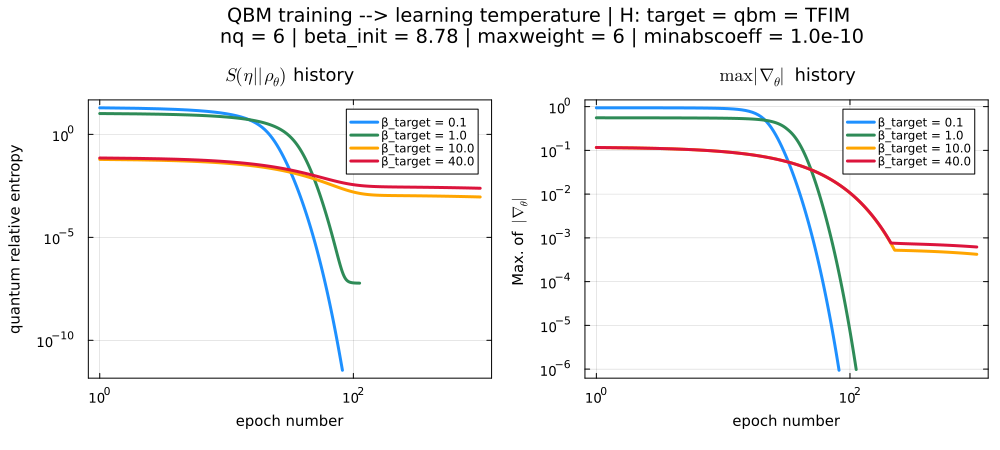

In [56]:
# Combine plots side by side
combined = plot(
    p1, p2,
    layout = (1, 2),
    size = (1000, 450),
    plot_title = "QBM training --> learning temperature | H: target = qbm = TFIM\n nq = 6 | beta_init = $(round(beta_qbm, digits=2)) | maxweight = $(max_weight_qbm) | minabscoeff = $(@sprintf("%.1e", min_abs_coeff_qbm))",
    plot_titlefont = font(13),
    bottom_margin = 9mm,  
    left_margin = 5mm,    
    right_margin = 1mm,
    top_margin = 10mm,
    framestyle = :box,
    titleloc = :center,
    spacing = 10mm
)

display(combined)


Starting optimization for max weight = 0.100
  [β_target=0.1 | epoch= 100]  QRE = 1.750036e-04   max|∇| = 1.300684e-03
  [β_target=0.1 | epoch= 200]  QRE = 1.634404e-04   max|∇| = 1.300684e-03
  [β_target=0.1 | epoch= 300]  QRE = 2.302755e-04   max|∇| = 1.300684e-03
  [β_target=0.1 | epoch= 400]  QRE = 2.173413e-04   max|∇| = 1.300684e-03
  [β_target=0.1 | epoch= 500]  QRE = 2.044331e-04   max|∇| = 1.300684e-03
  [β_target=0.1 | epoch= 600]  QRE = 1.914978e-04   max|∇| = 1.300684e-03
  [β_target=0.1 | epoch= 700]  QRE = 1.784776e-04   max|∇| = 1.300684e-03
  [β_target=0.1 | epoch= 800]  QRE = 1.676032e-04   max|∇| = 1.300684e-03
  [β_target=0.1 | epoch= 900]  QRE = 2.355138e-04   max|∇| = 8.792475e-03
  [β_target=0.1 | epoch=1000]  QRE = 2.209138e-04   max|∇| = 1.300684e-03

Finished β_target = 0.1  → epochs: 1000 | final QRE = 2.209138e-04 | final max|∇| = 1.301e-03
------------------------------------------------------------

Starting optimization for max weight = 1.000
Converged: m

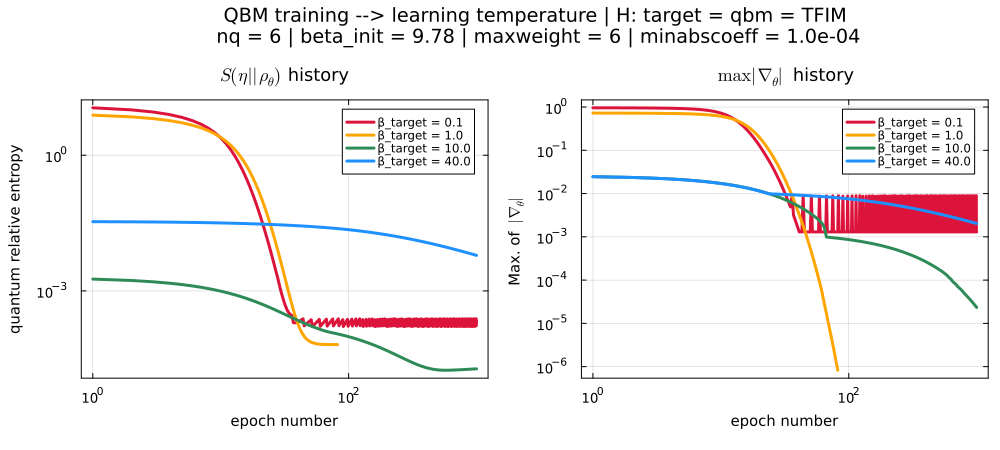

In [67]:
# ----------------------------- #
#  ---  EXPERIMENT SETUP   ---  #
# ----------------------------- #

nq = 6 

rng = MersenneTwister()

# target
## target β values to test
target_beta_values = [0.1, 1.0, 10.0, 40.0]
colors = [:crimson, :orange, :seagreen, :dodgerblue]

target_interaction = rand(rng, Uniform(-1, 1))
target_field = rand(rng, Uniform(-1, 1))
params_target = parameters(:tfim, nq; field_vals=Dict(:X => target_field), coupling_vals=Dict(:ZZ => target_interaction))
target_H_paulis = makehamiltonian(params_target; connectivity=:nearest, periodic=false) 

# learning rate
gamma = 0.2
# number of epochs
epochs = 1000
# stop when gradient is smaller than epsilon
epsilon = 1e-6

# QBM values
rng = MersenneTwister()
beta_qbm = rand(rng, Uniform(0, 10))
## truncation parameters
num_layers_qbm = 100
max_weight_qbm = nq
min_abs_coeff_qbm = 1e-4


# # Output path
# save_dir = "/Users/micheleminervini/Desktop/PauliSampling.jl/numerics/quantumboltzmannmachines/data"
# base_name = "targetTFIM_qbmTFIM_6qb_notrunc"

# ----------------------------- #
#  ---  INITIALIZE PLOTS   ---  #
# ----------------------------- #

# storage for plots
p1 = plot(
    yaxis = :log10,
    xaxis = :log10,
    xlabel = "epoch number",
    ylabel = "quantum relative entropy",
    title = "\n" * "\n" * string(L"S\left(\!\eta || \!\rho\!_\theta\!\right)", " history"),
    legend = :topright,
    lw = 3,
    titlefont = font(12),
    guidefont = font(10),
    tickfont = font(9),
    margin = 5mm
)

p2 = plot(
    yaxis = :log10,
    xaxis = :log10,
    xlabel = "epoch number",
    ylabel = "Max. of  " * L"|\!\nabla\!_\theta|",
    title = "\n" * "\n" * string(L"\max |\!\nabla\!_\theta|", " history"),
    legend = :topright,
    lw = 3,
    titlefont = font(12),
    guidefont = font(10),
    tickfont = font(9),
    margin = 5mm
)

# ----------------------------- #
#  ---  MAIN OPTIMIZATION   --- #
# ----------------------------- #

# Loop over target beta values
for (i, target_beta) in enumerate(target_beta_values)

    println("\n" * "="^60)
    @printf("Starting optimization for max weight = %.3f\n", target_beta)
    println("="^60)

    #  ---  TARGET STATE SETUP  --- #
    target_H_paulis_beta = target_H_paulis
    target_H_paulis_beta *= target_beta
    targert_circuit, target_θ = paulistringtocircuit(target_H_paulis_beta)
    num_layers_target = 100
    max_weight_target = nq
    min_abs_coeff_target = 1e-20
    target_eta = makethermalstate(nq, targert_circuit, target_θ, num_layers_target;
        max_weight=max_weight_target,
        min_abs_coeff=min_abs_coeff_target
    )
    target_eta_matrix = paulistringtomatrix(target_eta)
    target_probs = computesymmetriceigenvalues(target_eta_matrix)

    #  ---  QBM MODEL & OPTIM.  --- #
    qbm_H_paulis = makehamiltonian(params_target; connectivity=:nearest, periodic=true) * beta_qbm  

    # keep track of loss and gradients
    qre_hist = Float64[]
    grad_hist = Vector{Float64}[]

    for epoch in 1:epochs
        qbm_H_matrix = paulistringtomatrix(qbm_H_paulis)
        push!(qre_hist, computequantumrelativeentropy(target_eta_matrix, target_probs, qbm_H_matrix))

        # create qbm state
        circuit, theta = paulistringtocircuit(qbm_H_paulis)
        rho = makethermalstate(nq, circuit, theta, num_layers_qbm;
                                        max_weight=max_weight_qbm,
                                        min_abs_coeff=min_abs_coeff_qbm)
        rho_matrix = paulistringtomatrix(rho)

        # Compute and record gradient
        grads = computegradients(qbm_H_paulis, target_eta, rho)
        push!(grad_hist, abs.(grads))

        # Update parameters
        updatehamiltonian!(qbm_H_paulis, grads, gamma)

        # Print diagnostics every 100 epochs
        if epoch % 100 == 0
            @printf("  [β_target=%.1f | epoch=%4d]  QRE = %.6e   max|∇| = %.6e\n",
                    target_beta, epoch, qre_hist[end], maximum(grad_hist[end]))
        end

        # Stop if converged
        if maximum(grad_hist[end]) < epsilon
            println("Converged: max gradient < epsilon")
            break
        end
    end

    # Summary for this maximum weight
    @printf("\nFinished β_target = %.1f  → epochs: %d | final QRE = %.6e | final max|∇| = %.3e\n",
            target_beta, length(qre_hist), qre_hist[end], maximum(grad_hist[end]))
    println("-"^60)

    # # ------------------------- #
    # # --- SAVE DATA TO FILE --- #
    # # ------------------------- #

    # # Save optimization histories as CSV
    # df = DataFrame(epoch = 1:length(qre_hist),
    #                qre = qre_hist,
    #                max_grad = [maximum(g) for g in grad_hist])
    # csv_path = joinpath(save_dir, "$(base_name)_beta$(beta).csv")
    # CSV.write(csv_path, df)
    # @printf("  → Saved CSV data to %s\n", csv_path)

    # # Collect metadata only once per run
    # metadata = Dict(
    #     "timestamp" => string(now()),
    #     "model_target" => "TFIM",
    #     "model_qbm" => "TFIM",
    #     "n_qubits" => nq,
    #     "beta_target" => target_beta,
    #     "beta_qbm" => beta,
    #     "beta_values" => beta_values,
    #     "learning_rate" => gamma,
    #     "epochs" => epochs,
    #     "epsilon" => epsilon,
    #     "target_params" => Dict("wi_xyz" => params_target.wi_xyz,
    #                             "wij_xyz" => params_target.wij_xyz),
    #     "target_truncation" => Dict("max_weight" => max_weight_target,
    #                                 "min_abs_coeff" => min_abs_coeff_target,
    #                                 "num_layers" => num_layers_target),
    #     "qbm_truncation" => Dict("max_weight" => max_weight_qbm,
    #                              "min_abs_coeff" => min_abs_coeff_qbm,
    #                              "num_layers" => num_layers_qbm)
    # )

    # json_path = joinpath(save_dir, "$(base_name)_beta$(beta)_metadata.json")
    # JSON3.write(json_path, metadata; indent=2)
    # @printf("  → Saved metadata to %s\n", json_path)

    # ------------------------- #
    # --- ADD TO PLOTS --- #
    # ------------------------- #
    plot!(p1, qre_hist; label = "β_target = $(target_beta)", color = colors[i], lw = 3)
    plot!(p2, [maximum(g) for g in grad_hist];
          label = "β_target = $(target_beta)", color = colors[i], lw = 3)
end

# Combine plots side by side
combined = plot(
    p1, p2,
    layout = (1, 2),
    size = (1000, 450),
    plot_title = "QBM training --> learning temperature | H: target = qbm = TFIM\n nq = 6 | beta_init = $(round(beta_qbm, digits=2)) | maxweight = $(max_weight_qbm) | minabscoeff = $(@sprintf("%.1e", min_abs_coeff_qbm))",
    plot_titlefont = font(13),
    bottom_margin = 9mm,  
    left_margin = 5mm,    
    right_margin = 1mm,
    top_margin = 10mm,
    framestyle = :box,
    titleloc = :center,
    spacing = 10mm
)

display(combined)

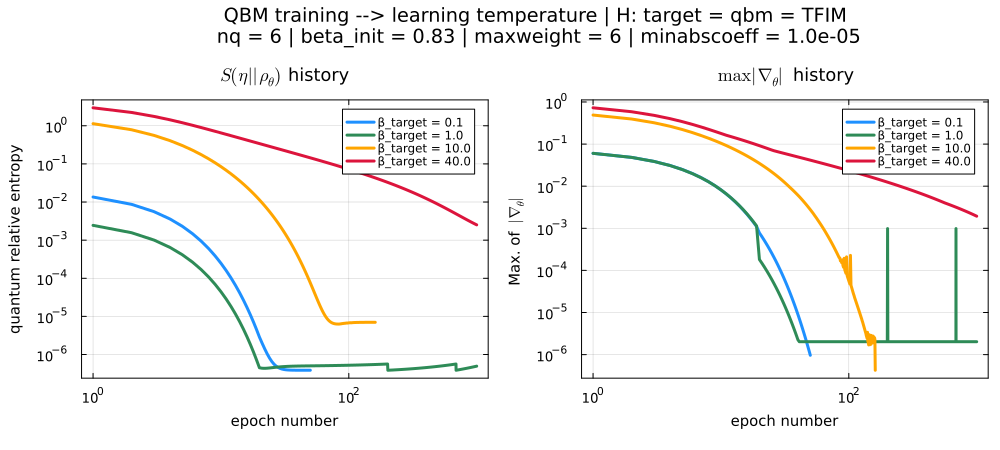

In [60]:
# Combine plots side by side
combined = plot(
    p1, p2,
    layout = (1, 2),
    size = (1000, 450),
    plot_title = "QBM training --> learning temperature | H: target = qbm = TFIM\n nq = 6 | beta_init = $(round(beta_qbm, digits=2)) | maxweight = $(max_weight_qbm) | minabscoeff = $(@sprintf("%.1e", min_abs_coeff_qbm))",
    plot_titlefont = font(13),
    bottom_margin = 9mm,  
    left_margin = 5mm,    
    right_margin = 1mm,
    top_margin = 10mm,
    framestyle = :box,
    titleloc = :center,
    spacing = 10mm
)

display(combined)


Starting optimization for β_target = 0.100 | min_abs_coeff = 1.0e-05
Converged: max gradient < epsilon

Finished β_target = 0.1 | minabs = 1.0e-05 → epochs: 71 | final QRE = 4.830422e-07 | final max|∇| = 8.877e-07
------------------------------------------------------------

Starting optimization for β_target = 1.000 | min_abs_coeff = 1.0e-05
  [β_target=1.0 | minabs=1.0e-05 | epoch= 100]  QRE = 8.872095e-07   max|∇| = 5.847432e-04
  [β_target=1.0 | minabs=1.0e-05 | epoch= 200]  QRE = 6.746738e-07   max|∇| = 7.173159e-04
  [β_target=1.0 | minabs=1.0e-05 | epoch= 300]  QRE = 7.096907e-07   max|∇| = 7.173159e-04
  [β_target=1.0 | minabs=1.0e-05 | epoch= 400]  QRE = 7.397990e-07   max|∇| = 7.173159e-04
  [β_target=1.0 | minabs=1.0e-05 | epoch= 500]  QRE = 7.655020e-07   max|∇| = 4.849373e-04
  [β_target=1.0 | minabs=1.0e-05 | epoch= 600]  QRE = 8.123036e-07   max|∇| = 5.246310e-04
  [β_target=1.0 | minabs=1.0e-05 | epoch= 700]  QRE = 8.526760e-07   max|∇| = 5.575442e-04
  [β_target=1.0 |

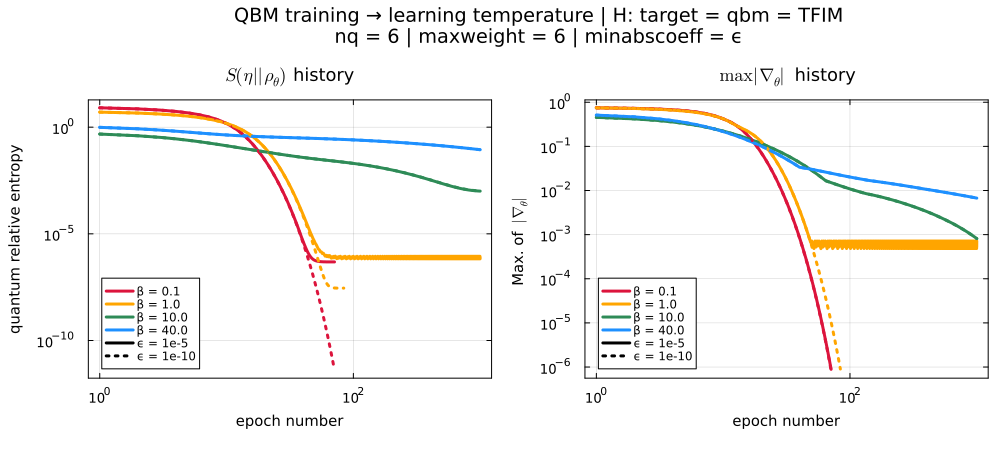

In [68]:
# ----------------------------- #
#  ---  EXPERIMENT SETUP   ---  #
# ----------------------------- #

nq = 6 

rng = MersenneTwister()

# target
## target β values to test
target_beta_values = [0.1, 1.0, 10.0, 40.0]
colors = [:crimson, :orange, :seagreen, :dodgerblue]

target_interaction = rand(rng, Uniform(-1, 1))
target_field = rand(rng, Uniform(-1, 1))
params_target = parameters(:tfim, nq; field_vals=Dict(:X => target_field), coupling_vals=Dict(:ZZ => target_interaction))
target_H_paulis = makehamiltonian(params_target; connectivity=:nearest, periodic=false) 

# learning rate
gamma = 0.2
epochs = 1000
epsilon = 1e-6

# QBM setup
rng = MersenneTwister()
beta_qbm = rand(rng, Uniform(0, 10))
num_layers_qbm = 100
max_weight_qbm = nq
min_abs_coeff_values = [1e-5, 1e-10]  # ε variants

# ----------------------------- #
#  ---  INITIALIZE PLOTS   ---  #
# ----------------------------- #

p1 = plot(
    yaxis = :log10,
    xaxis = :log10,
    xlabel = "epoch number",
    ylabel = "quantum relative entropy",
    title = "\n" * "\n" * string(L"S\left(\!\eta || \!\rho\!_\theta\!\right)", " history"),
    legend = :bottomleft,    
    lw = 3,
    titlefont = font(12),
    guidefont = font(10),
    tickfont = font(9),
    margin = 5mm,
    legendfontsize = 8,
)

p2 = plot(
    yaxis = :log10,
    xaxis = :log10,
    xlabel = "epoch number",
    ylabel = "Max. of  " * L"|\!\nabla\!_\theta|",
    title = "\n" * "\n" * string(L"\max |\!\nabla\!_\theta|", " history"),
    legend = :bottomleft,
    lw = 3,
    titlefont = font(12),
    guidefont = font(10),
    tickfont = font(9),
    margin = 5mm,
    legendfontsize = 8,
)

# ----------------------------- #
#  ---  MAIN OPTIMIZATION   --- #
# ----------------------------- #

for (j, min_abs_coeff_qbm) in enumerate(min_abs_coeff_values)
    line_style = (j == 1) ? :solid : :dot

    for (i, target_beta) in enumerate(target_beta_values)

        println("\n" * "="^60)
        @printf("Starting optimization for β_target = %.3f | min_abs_coeff = %.1e\n", target_beta, min_abs_coeff_qbm)
        println("="^60)

        # --- TARGET STATE SETUP ---
        target_H_paulis_beta = target_H_paulis * target_beta
        targert_circuit, target_θ = paulistringtocircuit(target_H_paulis_beta)
        num_layers_target = 100
        max_weight_target = nq
        min_abs_coeff_target = 1e-20
        target_eta = makethermalstate(nq, targert_circuit, target_θ, num_layers_target;
            max_weight=max_weight_target,
            min_abs_coeff=min_abs_coeff_target
        )
        target_eta_matrix = paulistringtomatrix(target_eta)
        target_probs = computesymmetriceigenvalues(target_eta_matrix)

        # --- QBM MODEL & OPTIMIZATION ---
        qbm_H_paulis = makehamiltonian(params_target; connectivity=:nearest, periodic=true) * beta_qbm  

        qre_hist = Float64[]
        grad_hist = Vector{Float64}[]

        for epoch in 1:epochs
            qbm_H_matrix = paulistringtomatrix(qbm_H_paulis)
            push!(qre_hist, computequantumrelativeentropy(target_eta_matrix, target_probs, qbm_H_matrix))

            circuit, theta = paulistringtocircuit(qbm_H_paulis)
            rho = makethermalstate(nq, circuit, theta, num_layers_qbm;
                                            max_weight=max_weight_qbm,
                                            min_abs_coeff=min_abs_coeff_qbm)
            rho_matrix = paulistringtomatrix(rho)

            grads = computegradients(qbm_H_paulis, target_eta, rho)
            push!(grad_hist, abs.(grads))
            updatehamiltonian!(qbm_H_paulis, grads, gamma)

            if epoch % 100 == 0
                @printf("  [β_target=%.1f | minabs=%.1e | epoch=%4d]  QRE = %.6e   max|∇| = %.6e\n",
                        target_beta, min_abs_coeff_qbm, epoch, qre_hist[end], maximum(grad_hist[end]))
            end

            if maximum(grad_hist[end]) < epsilon
                println("Converged: max gradient < epsilon")
                break
            end
        end

        @printf("\nFinished β_target = %.1f | minabs = %.1e → epochs: %d | final QRE = %.6e | final max|∇| = %.3e\n",
                target_beta, min_abs_coeff_qbm, length(qre_hist), qre_hist[end], maximum(grad_hist[end]))
        println("-"^60)

        # --- ADD TO PLOTS ---
        # Important: keep real series unlabeled so legend doesn't explode
        plot!(p1, qre_hist; label = "", color = colors[i], lw = 3, linestyle = line_style)
        plot!(p2, [maximum(g) for g in grad_hist];
              label = "", color = colors[i], lw = 3, linestyle = line_style)
    end
end

# ----------------------------- #
#  ---  SINGLE LEGEND ENTRIES --- #
# ----------------------------- #

# Add compact legend entries (dummy series) to p1 and p2

# (A) Color legend for β_target
for (i, β) in enumerate(target_beta_values)
    plot!(p1, [NaN], [NaN]; color = colors[i], lw = 3, linestyle = :solid, label = "β = $(β)")
    plot!(p2, [NaN], [NaN]; color = colors[i], lw = 3, linestyle = :solid, label = "β = $(β)")
end

# (B) Line-style legend for ε
plot!(p1, [NaN], [NaN]; color = :black, lw = 3, linestyle = :solid, label = "ϵ = 1e-5")
plot!(p1, [NaN], [NaN]; color = :black, lw = 3, linestyle = :dot,   label = "ϵ = 1e-10")

plot!(p2, [NaN], [NaN]; color = :black, lw = 3, linestyle = :solid, label = "ϵ = 1e-5")
plot!(p2, [NaN], [NaN]; color = :black, lw = 3, linestyle = :dot,   label = "ϵ = 1e-10")

# ----------------------------- #
#  ---  FINAL COMBINED PLOT --- #
# ----------------------------- #

combined = plot(
    p1, p2,
    layout = (1, 2),
    size = (1000, 450),
    plot_title = "QBM training → learning temperature | H: target = qbm = TFIM\nnq = 6 | maxweight = $(max_weight_qbm) | minabscoeff = ϵ",
    plot_titlefont = font(13),
    bottom_margin = 9mm,  
    left_margin = 5mm,    
    right_margin = 1mm,
    top_margin = 10mm,
    framestyle = :box,
    titleloc = :center,
    spacing = 10mm
)

display(combined)


Starting optimization for β_target = 0.100 | min_abs_coeff = 1.0e-10
Converged: max gradient < epsilon

Finished β_target = 0.1 | minabs = 1.0e-10 → epochs: 70 | final QRE = 4.503953e-12 | final max|∇| = 9.058e-07
------------------------------------------------------------

Starting optimization for β_target = 1.000 | min_abs_coeff = 1.0e-10
Converged: max gradient < epsilon

Finished β_target = 1.0 | minabs = 1.0e-10 → epochs: 80 | final QRE = 1.407703e-08 | final max|∇| = 9.302e-07
------------------------------------------------------------

Starting optimization for β_target = 5.000 | min_abs_coeff = 1.0e-10
  [β_target=5.0 | minabs=1.0e-10 | epoch= 100]  QRE = 1.042271e-03   max|∇| = 5.525926e-03
  [β_target=5.0 | minabs=1.0e-10 | epoch= 200]  QRE = 6.245481e-05   max|∇| = 3.297280e-04
  [β_target=5.0 | minabs=1.0e-10 | epoch= 300]  QRE = 5.674748e-05   max|∇| = 1.866631e-05
  [β_target=5.0 | minabs=1.0e-10 | epoch= 400]  QRE = 5.659584e-05   max|∇| = 1.020881e-06
Converged: max

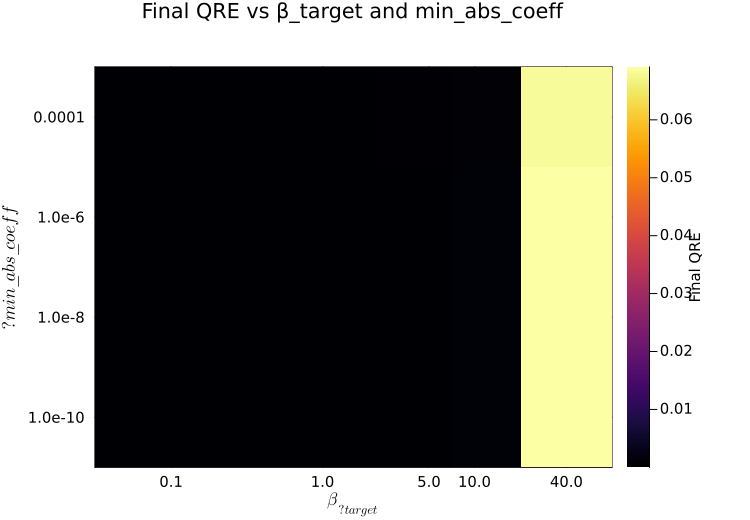

In [73]:
# ----------------------------- #
#  ---  EXPERIMENT SETUP   ---  #
# ----------------------------- #

nq = 6 

rng = MersenneTwister()

# target
## target β values to test
target_beta_values = [0.1, 1.0, 5.0, 10.0, 40.0]

target_interaction = rand(rng, Uniform(-1, 1))
target_field = rand(rng, Uniform(-1, 1))
params_target = parameters(:tfim, nq;
    field_vals = Dict(:X => target_field),
    coupling_vals = Dict(:ZZ => target_interaction)
)
target_H_paulis = makehamiltonian(params_target; connectivity = :nearest, periodic = false)

# learning rate
gamma   = 0.2
epochs  = 1000
epsilon = 1e-6

# QBM setup
rng = MersenneTwister()
beta_qbm        = rand(rng, Uniform(0, 10))
num_layers_qbm  = 100
max_weight_qbm  = nq
min_abs_coeff_values = sort([1e-4, 1e-6, 1e-8, 1e-10])

# ----------------------------- #
#  ---  STORAGE FOR RESULTS --- #
# ----------------------------- #
# final_qre[j, i] = final QRE for
#   j-th min_abs_coeff_values
#   i-th target_beta_values
final_qre = fill(NaN, length(min_abs_coeff_values), length(target_beta_values))

# ----------------------------- #
#  ---  MAIN OPTIMIZATION   --- #
# ----------------------------- #

for (j, min_abs_coeff_qbm) in enumerate(min_abs_coeff_values)

    for (i, target_beta) in enumerate(target_beta_values)

        println("\n" * "="^60)
        @printf("Starting optimization for β_target = %.3f | min_abs_coeff = %.1e\n",
                target_beta, min_abs_coeff_qbm)
        println("="^60)

        # --- TARGET STATE SETUP ---
        target_H_paulis_beta = target_H_paulis * target_beta
        targert_circuit, target_θ = paulistringtocircuit(target_H_paulis_beta)
        num_layers_target   = 100
        max_weight_target   = nq
        min_abs_coeff_target = 1e-20

        target_eta = makethermalstate(
            nq, targert_circuit, target_θ, num_layers_target;
            max_weight   = max_weight_target,
            min_abs_coeff = min_abs_coeff_target,
        )
        target_eta_matrix = paulistringtomatrix(target_eta)
        target_probs      = computesymmetriceigenvalues(target_eta_matrix)

        # --- QBM MODEL & OPTIMIZATION ---
        qbm_H_paulis = makehamiltonian(params_target; connectivity = :nearest, periodic = true) * beta_qbm  

        qre_hist  = Float64[]
        grad_hist = Vector{Float64}[]

        for epoch in 1:epochs
            qbm_H_matrix = paulistringtomatrix(qbm_H_paulis)
            push!(qre_hist,
                  computequantumrelativeentropy(target_eta_matrix, target_probs, qbm_H_matrix))

            circuit, theta = paulistringtocircuit(qbm_H_paulis)
            rho = makethermalstate(
                nq, circuit, theta, num_layers_qbm;
                max_weight   = max_weight_qbm,
                min_abs_coeff = min_abs_coeff_qbm,
            )
            rho_matrix = paulistringtomatrix(rho)

            grads = computegradients(qbm_H_paulis, target_eta, rho)
            push!(grad_hist, abs.(grads))
            updatehamiltonian!(qbm_H_paulis, grads, gamma)

            if epoch % 100 == 0
                @printf("  [β_target=%.1f | minabs=%.1e | epoch=%4d]  QRE = %.6e   max|∇| = %.6e\n",
                        target_beta, min_abs_coeff_qbm, epoch,
                        qre_hist[end], maximum(grad_hist[end]))
            end

            if maximum(grad_hist[end]) < epsilon
                println("Converged: max gradient < epsilon")
                break
            end
        end

        # store final QRE for this (β_target, ε)
        final_qre[j, i] = qre_hist[end]

        @printf(
            "\nFinished β_target = %.1f | minabs = %.1e → epochs: %d | final QRE = %.6e | final max|∇| = %.3e\n",
            target_beta, min_abs_coeff_qbm,
            length(qre_hist), qre_hist[end], maximum(grad_hist[end]),
        )
        println("-"^60)
    end
end

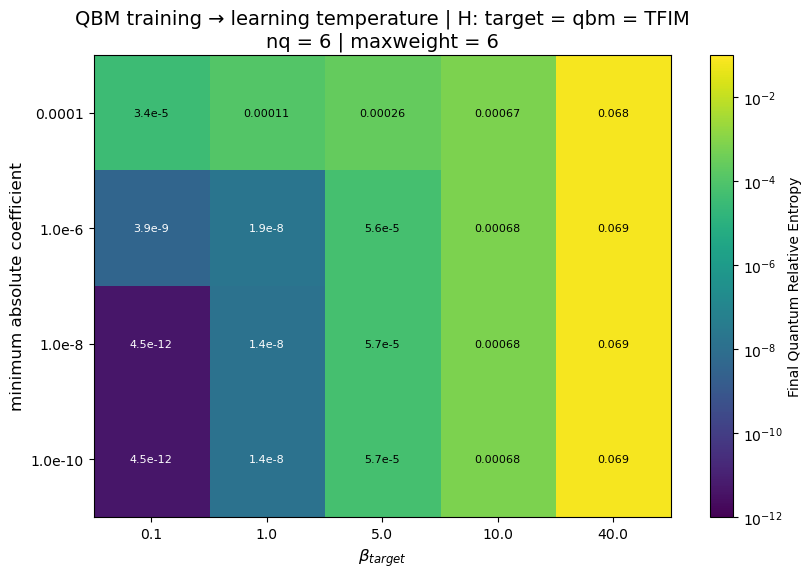

In [98]:
# ----------------------------- #
#      CREATE THE PLOT          #
# ----------------------------- #
# Close previous figures
PyPlot.close("all")

# Create figure and axis
fig, ax = subplots(figsize=(10, 6))

# Define the Logarithmic Normalization
# This tells the plot to map colors from 1e-12 to 1e-1 logarithmically
# vmin and vmax set the range for the colors
norm = PyPlot.matplotlib.colors.LogNorm(vmin=1e-12, vmax=1e-1)

# Plot using imshow
# origin="lower" ensures the first row (1e-10) is at the bottom
# aspect="auto" allows the squares to stretch if the window is resized (or use "equal" for squares)
im = ax.imshow(final_qre, norm=norm, cmap="viridis", origin="lower", aspect="equal")

# ----------------------------- #
#      TICKS AND LABELS         #
# ----------------------------- #
# imshow uses integer coordinates (0, 1, 2...), so we set ticks at those integers
# and replace the labels with your custom values.

# X-Axis
ax.set_xticks(0:length(target_beta_values)-1)
ax.set_xticklabels(string.(target_beta_values))
ax.set_xlabel(L"\beta_{target}", fontsize=12)

# Y-Axis
ax.set_yticks(0:length(min_abs_coeff_values)-1)
ax.set_yticklabels(string.(min_abs_coeff_values))
ax.set_ylabel("minimum absolute coefficient", fontsize=12)

ax.set_title("QBM training → learning temperature | H: target = qbm = TFIM\nnq = 6 | maxweight = $(max_weight_qbm)", fontsize=14)

# ----------------------------- #
#         COLORBAR              #
# ----------------------------- #
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Final Quantum Relative Entropy")

# Optional: Add text numbers on top of cells
# We loop over rows (i) and columns (j)
rows, cols = size(final_qre)
for i in 0:rows-1
    for j in 0:cols-1
        # Note: Julia is 1-indexed, Python/PyPlot is 0-indexed
        val = final_qre[i+1, j+1]
        
        # Determine text color based on brightness (white text on dark background)
        text_color = val < 1e-6 ? "white" : "black"
        
        ax.text(j, i, string(round(val, sigdigits=2)), 
                ha="center", va="center", color=text_color, fontsize=8)
    end
end

# Display
display(fig)

## 8 qubits

In [112]:
# ----------------------------- #
#  ---  EXPERIMENT SETUP   ---  #
# ----------------------------- #

nq = 8 

rng = MersenneTwister()

# target
## target β values to test
target_beta_values = [0.1, 1.0, 5.0, 10.0, 40.0]

target_interaction = rand(rng, Uniform(-1, 1))
target_field = rand(rng, Uniform(-1, 1))
params_target = parameters(:tfim, nq;
    field_vals = Dict(:X => target_field),
    coupling_vals = Dict(:ZZ => target_interaction)
)
target_H_paulis = makehamiltonian(params_target; connectivity = :nearest, periodic = false)

# learning rate
gamma   = 0.2
epochs  = 200
epsilon = 1e-6

# QBM setup
rng = MersenneTwister()
beta_qbm        = rand(rng, Uniform(0, 10))
num_layers_qbm  = 100
max_weight_qbm  = nq
min_abs_coeff_values = sort([1e-4, 1e-6, 1e-8, 1e-10])

# ----------------------------- #
#  ---  STORAGE FOR RESULTS --- #
# ----------------------------- #
# final_qre[j, i] = final QRE for
#   j-th min_abs_coeff_values
#   i-th target_beta_values
final_qre = fill(NaN, length(min_abs_coeff_values), length(target_beta_values))

# ----------------------------- #
#  ---  MAIN OPTIMIZATION   --- #
# ----------------------------- #

for (j, min_abs_coeff_qbm) in enumerate(min_abs_coeff_values)

    for (i, target_beta) in enumerate(target_beta_values)

        println("\n" * "="^60)
        @printf("Starting optimization for β_target = %.3f | min_abs_coeff = %.1e\n",
                target_beta, min_abs_coeff_qbm)
        println("="^60)

        # --- TARGET STATE SETUP ---
        target_H_paulis_beta = target_H_paulis * target_beta
        targert_circuit, target_θ = paulistringtocircuit(target_H_paulis_beta)
        num_layers_target   = 100
        max_weight_target   = nq
        min_abs_coeff_target = 1e-20

        target_eta = makethermalstate(
            nq, targert_circuit, target_θ, num_layers_target;
            max_weight   = max_weight_target,
            min_abs_coeff = min_abs_coeff_target,
        )
        target_eta_matrix = paulistringtomatrix(target_eta)
        target_probs      = computesymmetriceigenvalues(target_eta_matrix)

        # --- QBM MODEL & OPTIMIZATION ---
        qbm_H_paulis = makehamiltonian(params_target; connectivity = :nearest, periodic = true) * beta_qbm  

        qre_hist  = Float64[]
        grad_hist = Vector{Float64}[]

        for epoch in 1:epochs
            qbm_H_matrix = paulistringtomatrix(qbm_H_paulis)
            push!(qre_hist,
                  computequantumrelativeentropy(target_eta_matrix, target_probs, qbm_H_matrix))

            circuit, theta = paulistringtocircuit(qbm_H_paulis)
            rho = makethermalstate(
                nq, circuit, theta, num_layers_qbm;
                max_weight   = max_weight_qbm,
                min_abs_coeff = min_abs_coeff_qbm,
            )
            rho_matrix = paulistringtomatrix(rho)

            grads = computegradients(qbm_H_paulis, target_eta, rho)
            push!(grad_hist, abs.(grads))
            updatehamiltonian!(qbm_H_paulis, grads, gamma)

            if epoch % 100 == 0
                @printf("  [β_target=%.1f | minabs=%.1e | epoch=%4d]  QRE = %.6e   max|∇| = %.6e\n",
                        target_beta, min_abs_coeff_qbm, epoch,
                        qre_hist[end], maximum(grad_hist[end]))
            end

            if maximum(grad_hist[end]) < epsilon
                println("Converged: max gradient < epsilon")
                break
            end
        end

        # store final QRE for this (β_target, ε)
        final_qre[j, i] = qre_hist[end]

        @printf(
            "\nFinished β_target = %.1f | minabs = %.1e → epochs: %d | final QRE = %.6e | final max|∇| = %.3e\n",
            target_beta, min_abs_coeff_qbm,
            length(qre_hist), qre_hist[end], maximum(grad_hist[end]),
        )
        println("-"^60)
    end
end


Starting optimization for β_target = 0.100 | min_abs_coeff = 1.0e-10
Converged: max gradient < epsilon

Finished β_target = 0.1 | minabs = 1.0e-10 → epochs: 63 | final QRE = 6.304290e-12 | final max|∇| = 9.254e-07
------------------------------------------------------------

Starting optimization for β_target = 1.000 | min_abs_coeff = 1.0e-10
Converged: max gradient < epsilon

Finished β_target = 1.0 | minabs = 1.0e-10 → epochs: 69 | final QRE = 1.360070e-08 | final max|∇| = 9.416e-07
------------------------------------------------------------

Starting optimization for β_target = 5.000 | min_abs_coeff = 1.0e-10
  [β_target=5.0 | minabs=1.0e-10 | epoch= 100]  QRE = 9.806981e-05   max|∇| = 1.089922e-03
  [β_target=5.0 | minabs=1.0e-10 | epoch= 200]  QRE = 6.015765e-05   max|∇| = 3.145594e-05

Finished β_target = 5.0 | minabs = 1.0e-10 → epochs: 200 | final QRE = 6.015765e-05 | final max|∇| = 3.146e-05
------------------------------------------------------------

Starting optimization 

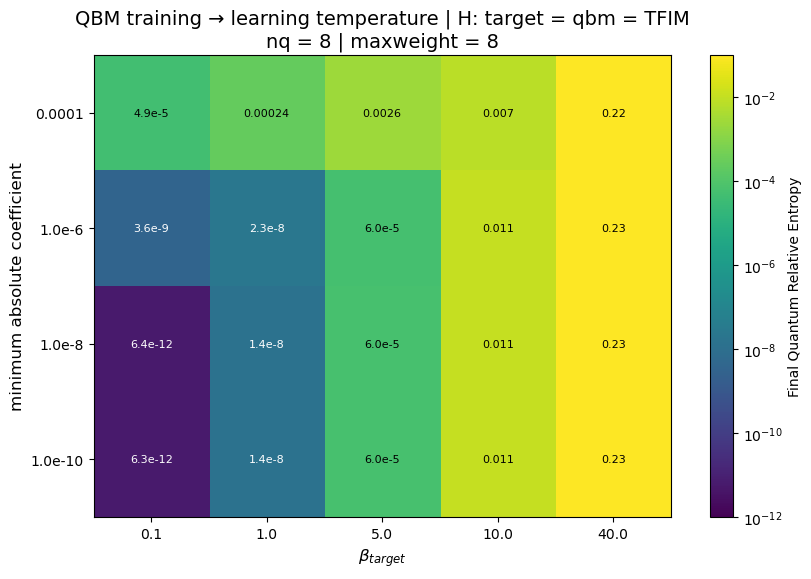

In [114]:
# ----------------------------- #
#      CREATE THE PLOT          #
# ----------------------------- #
# Close previous figures
PyPlot.close("all")

# Create figure and axis
fig, ax = subplots(figsize=(10, 6))

# Define the Logarithmic Normalization
# This tells the plot to map colors from 1e-12 to 1e-1 logarithmically
# vmin and vmax set the range for the colors
norm = PyPlot.matplotlib.colors.LogNorm(vmin=1e-12, vmax=1e-1)

# Plot using imshow
# origin="lower" ensures the first row (1e-10) is at the bottom
# aspect="auto" allows the squares to stretch if the window is resized (or use "equal" for squares)
im = ax.imshow(final_qre, norm=norm, cmap="viridis", origin="lower", aspect="equal")

# ----------------------------- #
#      TICKS AND LABELS         #
# ----------------------------- #
# imshow uses integer coordinates (0, 1, 2...), so we set ticks at those integers
# and replace the labels with your custom values.

# X-Axis
ax.set_xticks(0:length(target_beta_values)-1)
ax.set_xticklabels(string.(target_beta_values))
ax.set_xlabel(L"\beta_{target}", fontsize=12)

# Y-Axis
ax.set_yticks(0:length(min_abs_coeff_values)-1)
ax.set_yticklabels(string.(min_abs_coeff_values))
ax.set_ylabel("minimum absolute coefficient", fontsize=12)

ax.set_title("QBM training → learning temperature | H: target = qbm = TFIM\nnq = $(nq) | maxweight = $(max_weight_qbm)", fontsize=14)

# ----------------------------- #
#         COLORBAR              #
# ----------------------------- #
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Final Quantum Relative Entropy")

# Optional: Add text numbers on top of cells
# We loop over rows (i) and columns (j)
rows, cols = size(final_qre)
for i in 0:rows-1
    for j in 0:cols-1
        # Note: Julia is 1-indexed, Python/PyPlot is 0-indexed
        val = final_qre[i+1, j+1]
        
        # Determine text color based on brightness (white text on dark background)
        text_color = val < 1e-6 ? "white" : "black"
        
        ax.text(j, i, string(round(val, sigdigits=2)), 
                ha="center", va="center", color=text_color, fontsize=8)
    end
end

# Display
display(fig)

# Generic Hamiltonian

## 6 qubits

In [118]:
# ----------------------------- #
#  ---  EXPERIMENT SETUP   ---  #
# ----------------------------- #

nq = 6  

# target

## target hamiltonian
target_beta = 1
rng = MersenneTwister(42)
field_scale = 0.5       # typical order of magnitude for 1-local terms
coupling_scale = 0.2    # typical order for 2-local terms
# Initialize all parameters randomly
params_target = parameters(
    :generic, nq;
    init = :randn,
    field_scale = field_scale,
    coupling_scale = coupling_scale,
    rng = rng
)
target_H_paulis = makehamiltonian(params_target; connectivity=:nearest, periodic=false) * target_beta

## target state
targert_circuit, target_θ = paulistringtocircuit(target_H_paulis)
num_layers_target = 100
max_weight_target = nq
min_abs_coeff_target = 1e-20
target_eta = makethermalstate(nq, targert_circuit, target_θ, num_layers_target;
                                  max_weight=max_weight_target,
                                  min_abs_coeff=min_abs_coeff_target)
target_eta_matrix = paulistringtomatrix(target_eta)
target_probs = computesymmetriceigenvalues(target_eta_matrix)

# beta values 
weight_values = [nq, nq-1, nq-2, nq-3]
colors = [:dodgerblue, :seagreen, :orange, :crimson]

# learning rate
gamma = 0.2
# number of epochs
epochs = 1000
# stop when gradient is smaller than epsilon
epsilon = 1e-6

beta = rand(rng, Uniform(0, 10))      

# # Output path
# save_dir = "/Users/micheleminervini/Desktop/PauliSampling.jl/numerics/quantumboltzmannmachines/data"
# base_name = "targetTFIM_qbmTFIM_6qb_notrunc"

# ----------------------------- #
#  ---  INITIALIZE PLOTS   ---  #
# ----------------------------- #

# storage for plots
p1 = plot(
    yaxis = :log10,
    # xaxis = :log10,
    xlabel = "epoch number",
    ylabel = "quantum relative entropy",
    title = "\n" * "\n" * string(L"S\left(\!\eta || \!\rho\!_\theta\!\right)", " history"),
    legend = :topright,
    lw = 3,
    titlefont = font(12),
    guidefont = font(10),
    tickfont = font(9),
    margin = 5mm
)

p2 = plot(
    yaxis = :log10,
    # xaxis = :log10,
    xlabel = "epoch number",
    ylabel = "Max. of  " * L"|\!\nabla\!_\theta|",
    title = "\n" * "\n" * string(L"\max |\!\nabla\!_\theta|", " history"),
    legend = :topright,
    lw = 3,
    titlefont = font(12),
    guidefont = font(10),
    tickfont = font(9),
    margin = 5mm
)

# ----------------------------- #
#  ---  MAIN OPTIMIZATION   --- #
# ----------------------------- #

# Loop over maximum weight values
for (i, max_weight_qbm) in enumerate(weight_values)

    println("\n" * "="^60)
    @printf("Starting optimization for max weight = %d\n", max_weight_qbm)
    println("="^60)

    # QBM model
    qbm_H_paulis = makehamiltonian(params_target; connectivity=:nearest, periodic=true) * beta  
    ## truncation parameters
    num_layers_qbm = 100
    min_abs_coeff_qbm = 1e-10

    # keep track of loss and gradients
    qre_hist = Float64[]
    grad_hist = Vector{Float64}[]

    for epoch in 1:epochs
        qbm_H_matrix = paulistringtomatrix(qbm_H_paulis)
        push!(qre_hist, computequantumrelativeentropy(target_eta_matrix, target_probs, qbm_H_matrix))

        # create qbm state
        circuit, theta = paulistringtocircuit(qbm_H_paulis)
        rho = makethermalstate(nq, circuit, theta, num_layers_qbm;
                                        max_weight=max_weight_qbm,
                                        min_abs_coeff=min_abs_coeff_qbm)
        rho_matrix = paulistringtomatrix(rho)

        # Compute and record gradient
        grads = computegradients(qbm_H_paulis, target_eta, rho)
        push!(grad_hist, abs.(grads))

        # Update parameters
        updatehamiltonian!(qbm_H_paulis, grads, gamma)

        # Print diagnostics every 100 epochs
        if epoch % 100 == 0
            @printf("  [w=%d | epoch=%4d]  QRE = %.6e   max|∇| = %.6e\n",
                    max_weight_qbm, epoch, qre_hist[end], maximum(grad_hist[end]))
        end

        # Stop if converged
        if maximum(grad_hist[end]) < epsilon
            println("Converged: max gradient < epsilon")
            break
        end
    end

    # Summary for this maximum weight
    @printf("\nFinished max_weight = %d  → epochs: %d | final QRE = %.6e | final max|∇| = %.3e\n",
            max_weight_qbm, length(qre_hist), qre_hist[end], maximum(grad_hist[end]))
    println("-"^60)

    # # ------------------------- #
    # # --- SAVE DATA TO FILE --- #
    # # ------------------------- #

    # # Save optimization histories as CSV
    # df = DataFrame(epoch = 1:length(qre_hist),
    #                qre = qre_hist,
    #                max_grad = [maximum(g) for g in grad_hist])
    # csv_path = joinpath(save_dir, "$(base_name)_beta$(beta).csv")
    # CSV.write(csv_path, df)
    # @printf("  → Saved CSV data to %s\n", csv_path)

    # # Collect metadata only once per run
    # metadata = Dict(
    #     "timestamp" => string(now()),
    #     "model_target" => "TFIM",
    #     "model_qbm" => "TFIM",
    #     "n_qubits" => nq,
    #     "beta_target" => target_beta,
    #     "beta_qbm" => beta,
    #     "beta_values" => beta_values,
    #     "learning_rate" => gamma,
    #     "epochs" => epochs,
    #     "epsilon" => epsilon,
    #     "target_params" => Dict("wi_xyz" => params_target.wi_xyz,
    #                             "wij_xyz" => params_target.wij_xyz),
    #     "target_truncation" => Dict("max_weight" => max_weight_target,
    #                                 "min_abs_coeff" => min_abs_coeff_target,
    #                                 "num_layers" => num_layers_target),
    #     "qbm_truncation" => Dict("max_weight" => max_weight_qbm,
    #                              "min_abs_coeff" => min_abs_coeff_qbm,
    #                              "num_layers" => num_layers_qbm)
    # )

    # json_path = joinpath(save_dir, "$(base_name)_beta$(beta)_metadata.json")
    # JSON3.write(json_path, metadata; indent=2)
    # @printf("  → Saved metadata to %s\n", json_path)

    # ------------------------- #
    # --- ADD TO PLOTS --- #
    # ------------------------- #
    plot!(p1, qre_hist; label = "max weight = $(max_weight_qbm)", color = colors[i], lw = 3)
    plot!(p2, [maximum(g) for g in grad_hist];
          label = "max weight = $(max_weight_qbm)", color = colors[i], lw = 3)
end


Starting optimization for max weight = 6
  [w=6 | epoch= 100]  QRE = 4.233388e-05   max|∇| = 2.305019e-03
  [w=6 | epoch= 200]  QRE = 4.027606e-08   max|∇| = 1.636205e-06
Converged: max gradient < epsilon

Finished max_weight = 6  → epochs: 207 | final QRE = 4.030127e-08 | final max|∇| = 9.845e-07
------------------------------------------------------------

Starting optimization for max weight = 5
  [w=5 | epoch= 100]  QRE = 4.215147e-05   max|∇| = 2.303707e-03
  [w=5 | epoch= 200]  QRE = 5.284942e-08   max|∇| = 1.636365e-06
Converged: max gradient < epsilon

Finished max_weight = 5  → epochs: 207 | final QRE = 5.292118e-08 | final max|∇| = 9.847e-07
------------------------------------------------------------

Starting optimization for max weight = 4
  [w=4 | epoch= 100]  QRE = 4.324410e-05   max|∇| = 2.333441e-03
  [w=4 | epoch= 200]  QRE = 1.072047e-06   max|∇| = 1.675427e-06
Converged: max gradient < epsilon

Finished max_weight = 4  → epochs: 208 | final QRE = 1.072533e-06 | fin

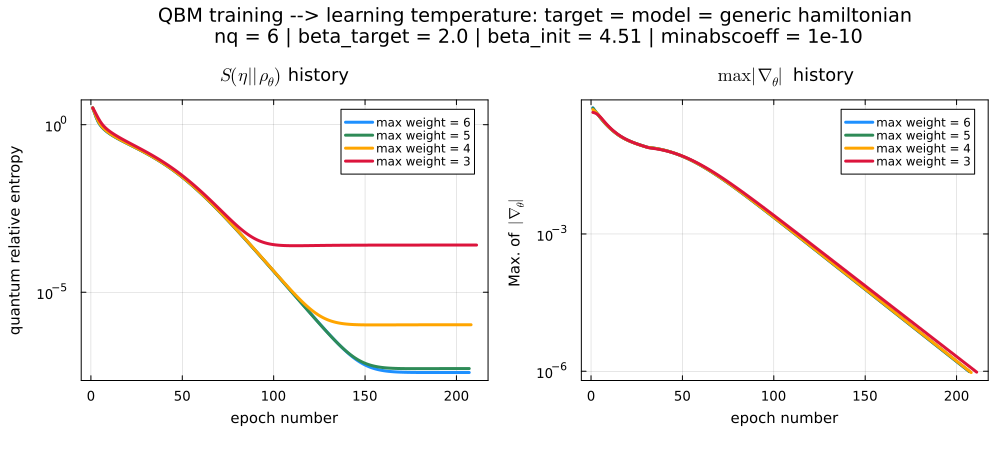

In [119]:
# Combine plots side by side
combined = plot(
    p1, p2,
    layout = (1, 2),
    size = (1000, 450),
    plot_title = "QBM training --> learning temperature: target = model = generic hamiltonian\n nq = 6 | beta_target = 2.0 | beta_init = $(round(beta, digits=2)) | minabscoeff = 1e-10",
    plot_titlefont = font(13),
    bottom_margin = 9mm,  
    left_margin = 5mm,    
    right_margin = 1mm,
    top_margin = 10mm,
    framestyle = :box,
    titleloc = :center,
    spacing = 10mm
)

display(combined)

# XYZ Heisenberg

## 8 qubits

In [123]:
# ----------------------------- #
#  ---  EXPERIMENT SETUP   ---  #
# ----------------------------- #

nq = 8  

# target

## target hamiltonian
target_beta = 1
rng = MersenneTwister(42)
field_scale = 0.5       # typical order of magnitude for 1-local terms
coupling_scale = 0.2    # typical order for 2-local terms
# Initialize all parameters randomly
params_target = parameters(
    :heisenberg_fields, nq;
    init = :randn,
    field_scale = field_scale,
    coupling_scale = coupling_scale,
    rng = rng
)
target_H_paulis = makehamiltonian(params_target; connectivity=:nearest, periodic=false) * target_beta

## target state
targert_circuit, target_θ = paulistringtocircuit(target_H_paulis)
num_layers_target = 10
max_weight_target = nq
min_abs_coeff_target = 1e-20
target_eta = makethermalstate(nq, targert_circuit, target_θ, num_layers_target;
                                  max_weight=max_weight_target,
                                  min_abs_coeff=min_abs_coeff_target)
target_eta_matrix = paulistringtomatrix(target_eta)
target_probs = computesymmetriceigenvalues(target_eta_matrix)

# beta values 
weight_values = [nq, nq-2, nq-4, nq-6]
colors = [:dodgerblue, :seagreen, :orange, :crimson]

# learning rate
gamma = 0.2
# number of epochs
epochs = 1000
# stop when gradient is smaller than epsilon
epsilon = 1e-6

beta = rand(rng, Uniform(0, 10))      

# # Output path
# save_dir = "/Users/micheleminervini/Desktop/PauliSampling.jl/numerics/quantumboltzmannmachines/data"
# base_name = "targetTFIM_qbmTFIM_6qb_notrunc"

# ----------------------------- #
#  ---  INITIALIZE PLOTS   ---  #
# ----------------------------- #

# storage for plots
p1 = plot(
    yaxis = :log10,
    # xaxis = :log10,
    xlabel = "epoch number",
    ylabel = "quantum relative entropy",
    title = "\n" * "\n" * string(L"S\left(\!\eta || \!\rho\!_\theta\!\right)", " history"),
    legend = :topright,
    lw = 3,
    titlefont = font(12),
    guidefont = font(10),
    tickfont = font(9),
    margin = 5mm
)

p2 = plot(
    yaxis = :log10,
    # xaxis = :log10,
    xlabel = "epoch number",
    ylabel = "Max. of  " * L"|\!\nabla\!_\theta|",
    title = "\n" * "\n" * string(L"\max |\!\nabla\!_\theta|", " history"),
    legend = :topright,
    lw = 3,
    titlefont = font(12),
    guidefont = font(10),
    tickfont = font(9),
    margin = 5mm
)

# ----------------------------- #
#  ---  MAIN OPTIMIZATION   --- #
# ----------------------------- #

# Loop over maximum weight values
for (i, max_weight_qbm) in enumerate(weight_values)

    println("\n" * "="^60)
    @printf("Starting optimization for max weight = %d\n", max_weight_qbm)
    println("="^60)

    # QBM model
    qbm_H_paulis = makehamiltonian(params_target; connectivity=:nearest, periodic=true) * beta  
    ## truncation parameters
    num_layers_qbm = 10
    min_abs_coeff_qbm = 1e-10

    # keep track of loss and gradients
    qre_hist = Float64[]
    grad_hist = Vector{Float64}[]

    for epoch in 1:epochs
        qbm_H_matrix = paulistringtomatrix(qbm_H_paulis)
        push!(qre_hist, computequantumrelativeentropy(target_eta_matrix, target_probs, qbm_H_matrix))

        # create qbm state
        circuit, theta = paulistringtocircuit(qbm_H_paulis)
        rho = makethermalstate(nq, circuit, theta, num_layers_qbm;
                                        max_weight=max_weight_qbm,
                                        min_abs_coeff=min_abs_coeff_qbm)
        rho_matrix = paulistringtomatrix(rho)

        # Compute and record gradient
        grads = computegradients(qbm_H_paulis, target_eta, rho)
        push!(grad_hist, abs.(grads))

        # Update parameters
        updatehamiltonian!(qbm_H_paulis, grads, gamma)

        # Print diagnostics every 100 epochs
        if epoch % 100 == 0
            @printf("  [w=%d | epoch=%4d]  QRE = %.6e   max|∇| = %.6e\n",
                    max_weight_qbm, epoch, qre_hist[end], maximum(grad_hist[end]))
        end

        # Stop if converged
        if maximum(grad_hist[end]) < epsilon
            println("Converged: max gradient < epsilon")
            break
        end
    end

    # Summary for this maximum weight
    @printf("\nFinished max_weight = %d  → epochs: %d | final QRE = %.6e | final max|∇| = %.3e\n",
            max_weight_qbm, length(qre_hist), qre_hist[end], maximum(grad_hist[end]))
    println("-"^60)

    # # ------------------------- #
    # # --- SAVE DATA TO FILE --- #
    # # ------------------------- #

    # # Save optimization histories as CSV
    # df = DataFrame(epoch = 1:length(qre_hist),
    #                qre = qre_hist,
    #                max_grad = [maximum(g) for g in grad_hist])
    # csv_path = joinpath(save_dir, "$(base_name)_beta$(beta).csv")
    # CSV.write(csv_path, df)
    # @printf("  → Saved CSV data to %s\n", csv_path)

    # # Collect metadata only once per run
    # metadata = Dict(
    #     "timestamp" => string(now()),
    #     "model_target" => "TFIM",
    #     "model_qbm" => "TFIM",
    #     "n_qubits" => nq,
    #     "beta_target" => target_beta,
    #     "beta_qbm" => beta,
    #     "beta_values" => beta_values,
    #     "learning_rate" => gamma,
    #     "epochs" => epochs,
    #     "epsilon" => epsilon,
    #     "target_params" => Dict("wi_xyz" => params_target.wi_xyz,
    #                             "wij_xyz" => params_target.wij_xyz),
    #     "target_truncation" => Dict("max_weight" => max_weight_target,
    #                                 "min_abs_coeff" => min_abs_coeff_target,
    #                                 "num_layers" => num_layers_target),
    #     "qbm_truncation" => Dict("max_weight" => max_weight_qbm,
    #                              "min_abs_coeff" => min_abs_coeff_qbm,
    #                              "num_layers" => num_layers_qbm)
    # )

    # json_path = joinpath(save_dir, "$(base_name)_beta$(beta)_metadata.json")
    # JSON3.write(json_path, metadata; indent=2)
    # @printf("  → Saved metadata to %s\n", json_path)

    # ------------------------- #
    # --- ADD TO PLOTS --- #
    # ------------------------- #
    plot!(p1, qre_hist; label = "max weight = $(max_weight_qbm)", color = colors[i], lw = 3)
    plot!(p2, [maximum(g) for g in grad_hist];
          label = "max weight = $(max_weight_qbm)", color = colors[i], lw = 3)
end


Starting optimization for max weight = 8
  [w=8 | epoch= 100]  QRE = 6.590487e-03   max|∇| = 3.138068e-02
  [w=8 | epoch= 200]  QRE = 7.631528e-06   max|∇| = 5.440930e-06
Converged: max gradient < epsilon

Finished max_weight = 8  → epochs: 220 | final QRE = 7.621881e-06 | final max|∇| = 9.257e-07
------------------------------------------------------------

Starting optimization for max weight = 6
  [w=6 | epoch= 100]  QRE = 6.620823e-03   max|∇| = 3.145361e-02
  [w=6 | epoch= 200]  QRE = 7.631991e-06   max|∇| = 5.455892e-06
Converged: max gradient < epsilon

Finished max_weight = 6  → epochs: 220 | final QRE = 7.622318e-06 | final max|∇| = 9.282e-07
------------------------------------------------------------

Starting optimization for max weight = 4
  [w=4 | epoch= 100]  QRE = 7.871337e-03   max|∇| = 3.428130e-02
  [w=4 | epoch= 200]  QRE = 8.427748e-06   max|∇| = 6.143357e-06
Converged: max gradient < epsilon

Finished max_weight = 4  → epochs: 221 | final QRE = 8.417048e-06 | fin

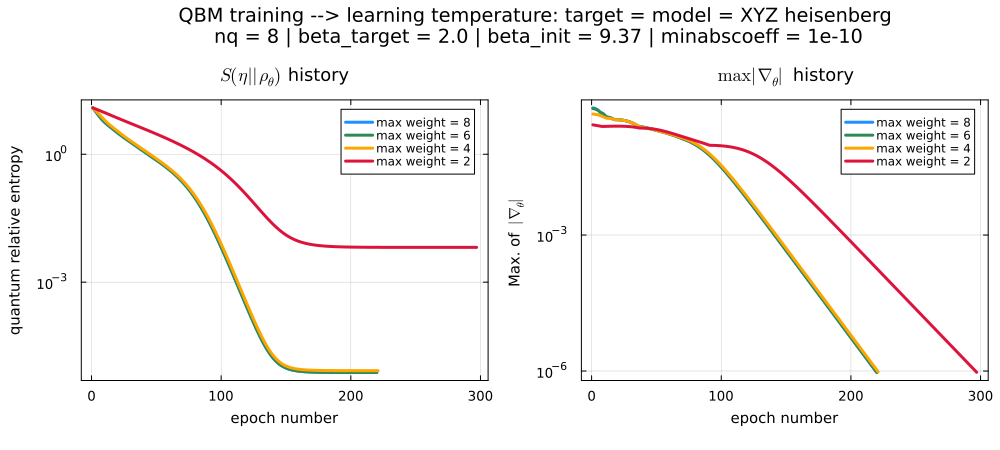

In [125]:
# Combine plots side by side
combined = plot(
    p1, p2,
    layout = (1, 2),
    size = (1000, 450),
    plot_title = "QBM training --> learning temperature: target = model = XYZ heisenberg\n nq = 8 | beta_target = 2.0 | beta_init = $(round(beta, digits=2)) | minabscoeff = 1e-10",
    plot_titlefont = font(13),
    bottom_margin = 9mm,  
    left_margin = 5mm,    
    right_margin = 1mm,
    top_margin = 10mm,
    framestyle = :box,
    titleloc = :center,
    spacing = 10mm
)

display(combined)